# 🛒 Sales Forecast Simulator — Entrenamiento del modelo

Notebook de entrenamiento y validación del modelo de predicción de ventas usado en la app
de Streamlit (`sales-forecast-simulator`).

**Objetivo:** predecir unidades vendidas diarias para 24 productos de una tienda de
e-commerce deportivo, a partir de precio, competencia y señales de fecha (Black Friday,
Cyber Monday, festivos).

**Flujo de este notebook:**
1. Carga y validación de datos
2. Análisis exploratorio (EDA)
3. Feature engineering (precio vs. competencia, señales de fecha especial)
4. Split temporal (2021-2023 train / 2024 validación)
5. Comparación de 3 configuraciones de features
6. Entrenamiento del modelo final con el 100% de los datos históricos
7. Generación del dataset de inferencia para noviembre 2025

In [1]:
import sys
print(sys.executable)
print(sys.version)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import holidays

/usr/bin/python3
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


## 0. Fijar versión de scikit-learn

Se fija `scikit-learn==1.9.0` porque es la versión que instala Streamlit Community Cloud
sin conflictos con Python 3.14. Entrenar y guardar el modelo con esta misma versión evita
errores de compatibilidad al cargarlo en producción (`No module named '_loss'`).

In [2]:
!pip install -q --upgrade scikit-learn==1.9.0

import sklearn
print("scikit-learn version:", sklearn.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 91.0 MB/s eta 0:00:00
scikit-learn version: 1.9.0


## 1. Carga de datos

In [3]:
df_ventas = pd.read_csv('/content/ventas.csv')
df_competencia = pd.read_csv('/content/competencia.csv')

df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])
df_competencia['fecha'] = pd.to_datetime(df_competencia['fecha'])

print("Ventas:")
print(df_ventas.head())
print()
print("Competencia:")
print(df_competencia.head())
print()
print(df_ventas.info())
print()
print(df_competencia.info())

Ventas:
       fecha producto_id                            nombre categoria  \
0 2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1 2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2 2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3 2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4 2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  
0        118.36    710.16  
1        136.82   1368.20  
2         84.93    169.86  
3         75.42    150.84 

## 2. Validación de calidad de los datos

In [4]:
print('=== VALIDACION DE CALIDAD DE df_ventas ===')
print('Dimensiones:', df_ventas.shape)
print()

print('Tipos de variables:')
print(df_ventas.dtypes)
print()

print('Valores nulos por columna:')
print(df_ventas.isna().sum())
print()

duplicados = df_ventas.duplicated().sum()
print("Numero de filas duplicadas:", duplicados)
print()

print('Resumen descriptivo:')
print(df_ventas.describe(include='all').T)
print()

print('=== INFORME FINAL DE CALIDAD DE DATOS DE VENTAS ===')
if df_ventas.isnull().sum().sum() == 0:
    print("No hay valores nulos")
else:
    print("Hay valores nulos")

if duplicados == 0:
    print("No hay filas duplicadas")
else:
    print(f"Hay {duplicados} filas duplicadas")

=== VALIDACION DE CALIDAD DE df_ventas ===
Dimensiones: (3552, 10)

Tipos de variables:
fecha                datetime64[ns]
producto_id                  object
nombre                       object
categoria                    object
subcategoria                 object
precio_base                   int64
es_estrella                    bool
unidades_vendidas             int64
precio_venta                float64
ingresos                    float64
dtype: object

Valores nulos por columna:
fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
dtype: int64

Numero de filas duplicadas: 0

Resumen descriptivo:
                    count unique                       top  freq  \
fecha                3552    NaN                       NaN   NaN   
producto_id          3552     24                  PROD_001   148   
nombre    

## 3. Unión de los dataframes de ventas y competencia

In [5]:
df_completo = pd.merge(
    df_ventas,
    df_competencia,
    how='inner',
    on=['fecha', 'producto_id']
)

df_completo['fecha'] = pd.to_datetime(df_completo['fecha'])
df_completo['mes'] = df_completo['fecha'].dt.strftime('%Y-%m')
df_completo['Año'] = df_completo['fecha'].dt.year

df_completo.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage,mes,Año
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43,2021-10,2021
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58,2021-10,2021
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11,2021-10,2021
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45,2021-10,2021
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07,2021-10,2021


## 4. Análisis exploratorio (EDA)

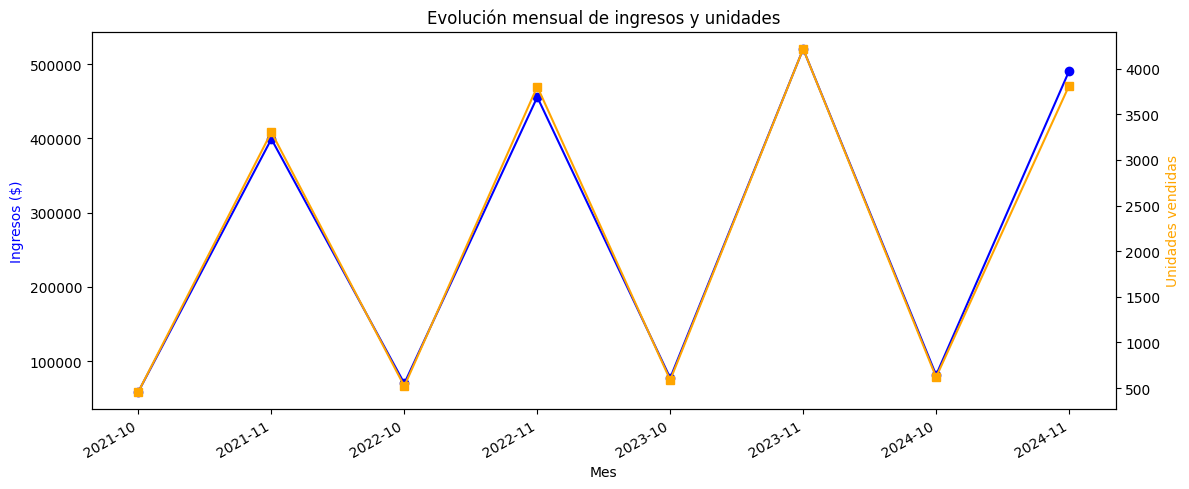

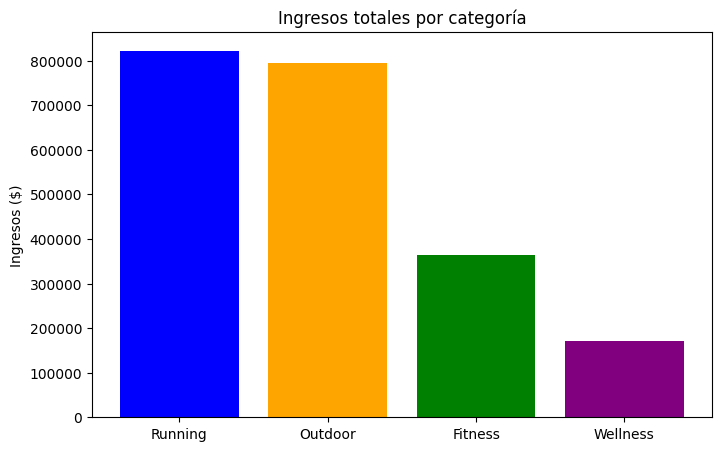

categoria
Running     822447.65
Outdoor     795547.67
Fitness     363917.04
Wellness    170501.33
Name: ingresos, dtype: float64


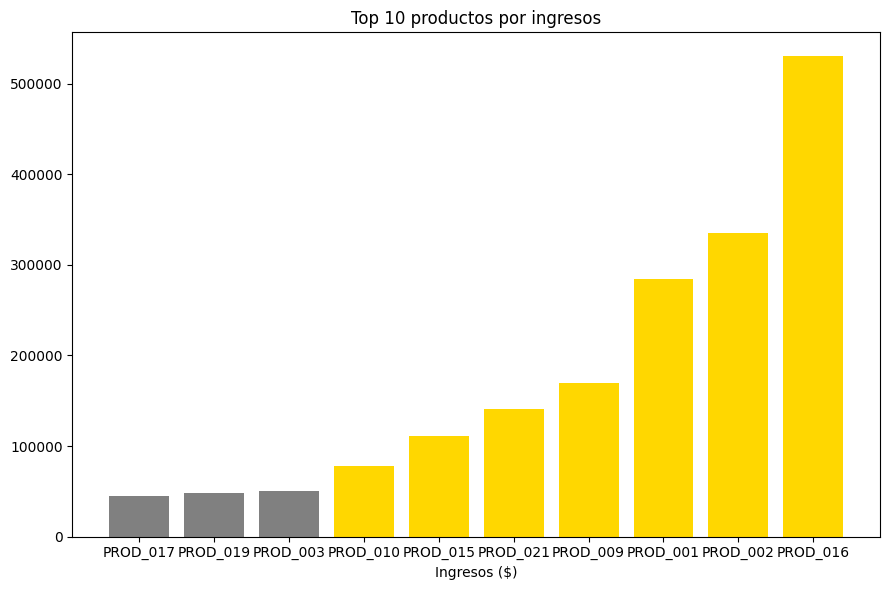

   es_estrella  ingresos_prom  unidades_prom  ingresos_total
0        False     199.939324       3.470986       503047.34
1         True    1592.052461       8.297297      1649366.35


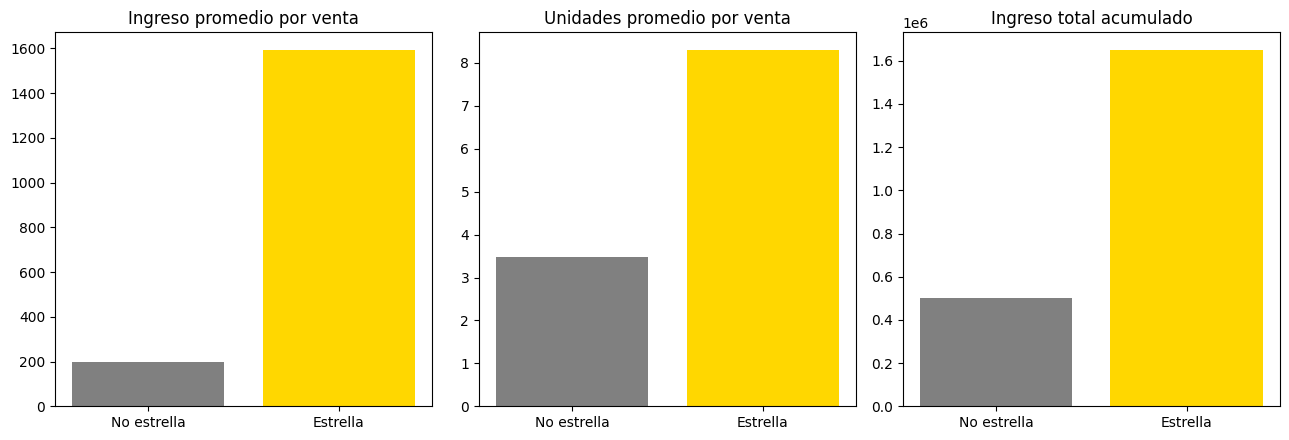

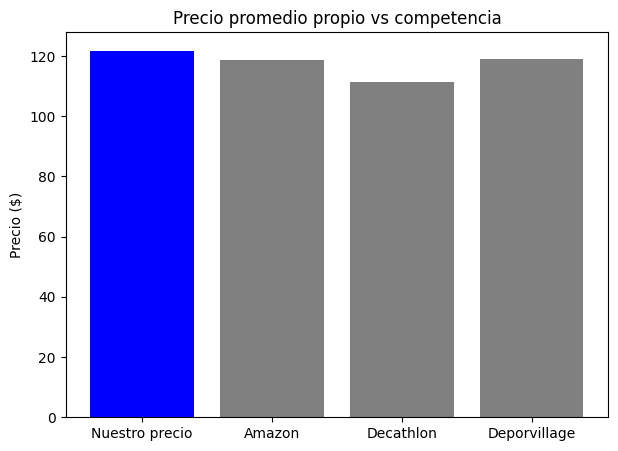

precio_venta    121.816546
Amazon          118.623407
Decathlon       111.412182
Deporvillage    118.894628
dtype: float64


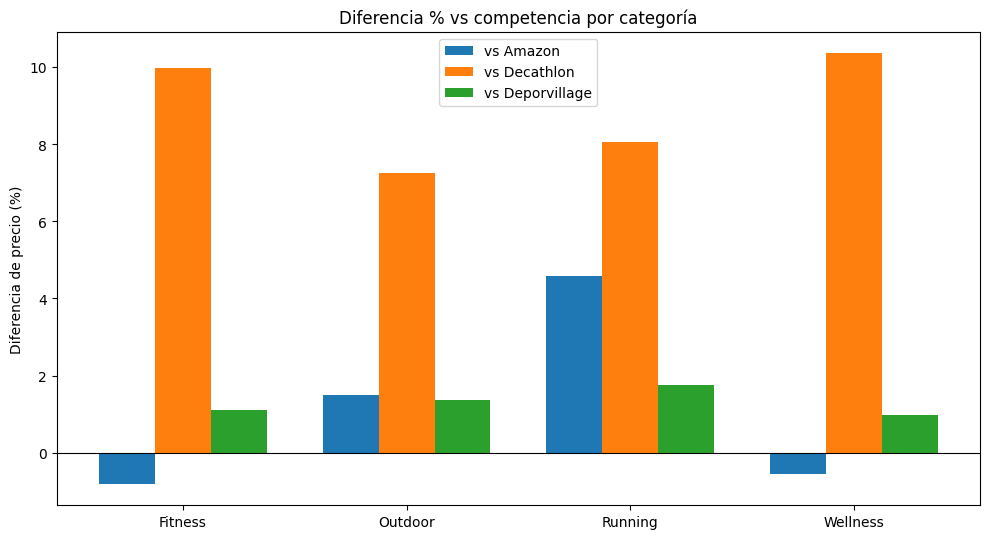

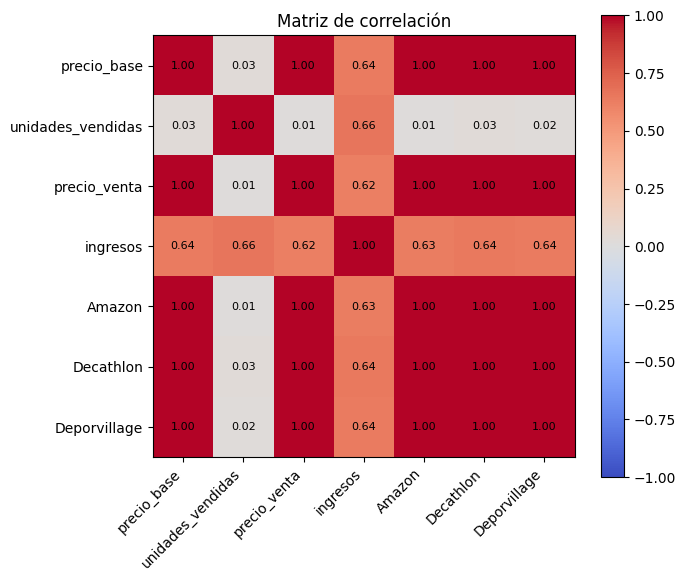

In [7]:
## Evolución mensual (ingresos y unidades)
monthly = df_completo.groupby('mes').agg(ingresos=('ingresos', 'sum'), unidades=('unidades_vendidas', 'sum')).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly['mes'], monthly['ingresos'], color='blue', marker='o', label='Ingresos')
ax1.set_ylabel('Ingresos ($)', color='blue')
ax1.set_xlabel('Mes')

ax2 = ax1.twinx()
ax2.plot(monthly['mes'], monthly['unidades'], color='orange', marker='s', label='Unidades')
ax2.set_ylabel('Unidades vendidas', color='orange')

plt.title('Evolución mensual de ingresos y unidades')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Ingresos por categoría
cat = df_completo.groupby('categoria')['ingresos'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(cat.index, cat.values, color=['blue', 'orange', 'green', 'purple'])
plt.title('Ingresos totales por categoría')
plt.ylabel('Ingresos ($)')
plt.show()
print(cat)

## Top 10 productos
prod = df_completo.groupby(['producto_id', 'es_estrella'])['ingresos'].sum().reset_index()
prod = prod.sort_values('ingresos', ascending=False).head(10)
colors = ['gold' if x else 'gray' for x in prod['es_estrella']]

plt.figure(figsize=(9, 6))
plt.bar(prod['producto_id'][::-1], prod['ingresos'][::-1], color=colors[::-1])
plt.title('Top 10 productos por ingresos')
plt.xlabel('Ingresos ($)')
plt.tight_layout()
plt.show()

## Estrella vs no estrella
star = df_completo.groupby('es_estrella').agg(
    ingresos_prom=('ingresos', 'mean'),
    unidades_prom=('unidades_vendidas', 'mean'),
    ingresos_total=('ingresos', 'sum')
).reset_index()
print(star)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
labels = ['No estrella', 'Estrella']
axes[0].bar(labels, star['ingresos_prom'], color=['gray', 'gold'])
axes[0].set_title('Ingreso promedio por venta')
axes[1].bar(labels, star['unidades_prom'], color=['gray', 'gold'])
axes[1].set_title('Unidades promedio por venta')
axes[2].bar(labels, star['ingresos_total'], color=['gray', 'gold'])
axes[2].set_title('Ingreso total acumulado')
plt.tight_layout()
plt.show()

## Precio propio vs competencia
precio_comp = df_completo[['precio_venta', 'Amazon', 'Decathlon', 'Deporvillage']].mean()

plt.figure(figsize=(7, 5))
plt.bar(['Nuestro precio', 'Amazon', 'Decathlon', 'Deporvillage'], precio_comp.values,
        color=['blue', 'gray', 'gray', 'gray'])
plt.title('Precio promedio propio vs competencia')
plt.ylabel('Precio ($)')
plt.show()
print(precio_comp)

## Diferencia % de precio vs competencia (se usa como feature del modelo)
df_completo['dif_amazon_pct'] = (df_completo['precio_venta'] - df_completo['Amazon']) / df_completo['Amazon'] * 100
df_completo['dif_decathlon_pct'] = (df_completo['precio_venta'] - df_completo['Decathlon']) / df_completo['Decathlon'] * 100
df_completo['dif_deporvillage_pct'] = (df_completo['precio_venta'] - df_completo['Deporvillage']) / df_completo['Deporvillage'] * 100

dif_cat = df_completo.groupby('categoria')[['dif_amazon_pct', 'dif_decathlon_pct', 'dif_deporvillage_pct']].mean()

x = np.arange(len(dif_cat.index))
width = 0.25
plt.figure(figsize=(10, 5.5))
plt.bar(x - width, dif_cat['dif_amazon_pct'], width, label='vs Amazon')
plt.bar(x, dif_cat['dif_decathlon_pct'], width, label='vs Decathlon')
plt.bar(x + width, dif_cat['dif_deporvillage_pct'], width, label='vs Deporvillage')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(x, dif_cat.index)
plt.ylabel('Diferencia de precio (%)')
plt.title('Diferencia % vs competencia por categoría')
plt.legend()
plt.tight_layout()
plt.show()

## Correlación entre variables numéricas
num_cols = ['precio_base', 'unidades_vendidas', 'precio_venta', 'ingresos', 'Amazon', 'Decathlon', 'Deporvillage']
corr = df_completo[num_cols].corr()

plt.figure(figsize=(7, 6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha='right')
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar()
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

## 5. Modelización con Machine Learning

**Decisiones tomadas antes de entrenar (y por qué):**

- **No se usan lags ni media móvil de unidades vendidas.** Se exploraron durante el
  desarrollo, pero requieren predicción recursiva día a día (cada predicción alimentando
  el lag siguiente), sumando complejidad y riesgo de propagación de error sin evidencia
  de que mejoraran el resultado frente a variables de precio/competencia/fecha.
- **No se usa one-hot encoding de producto/categoría.** Con pocos registros por producto,
  agregar ~50 columnas dummy aumenta el riesgo de sobreajuste sin aportar señal más allá
  de la que ya capturan `es_estrella` y el precio.

Se comparan 3 configuraciones de features para decidir cuál desplegar.

### 5.1 Agregar señales de fecha especial (Black Friday / Cyber Monday / festivos)

In [8]:
def es_black_friday(fecha):
    if fecha.month == 11:
        nov_dates = pd.date_range(start=f'{fecha.year}-11-01', end=f'{fecha.year}-11-30', freq='D')
        fridays = nov_dates[nov_dates.weekday == 4]
        if not fridays.empty:
            return fecha == fridays[-1]
    return False


def es_cyber_monday(fecha):
    nov_dates = pd.date_range(start=f'{fecha.year}-11-01', end=f'{fecha.year}-11-30', freq='D')
    fridays_in_nov = nov_dates[nov_dates.weekday == 4]
    if not fridays_in_nov.empty:
        black_friday_date = fridays_in_nov[-1]
        cyber_monday_date = black_friday_date + pd.Timedelta(days=3)
        return fecha == cyber_monday_date
    return False


df_completo['fecha'] = pd.to_datetime(df_completo['fecha'])
df_completo['es_black_friday'] = df_completo['fecha'].apply(es_black_friday)
df_completo['es_cyber_monday'] = df_completo['fecha'].apply(es_cyber_monday)

es_holidays = holidays.Spain()
df_completo['es_festivo'] = df_completo['fecha'].apply(lambda x: x in es_holidays)

print(df_completo[['es_black_friday', 'es_cyber_monday', 'es_festivo']].sum())

es_black_friday    96
es_cyber_monday    72
es_festivo         96
dtype: int64


### 5.2 Split temporal (entrenamiento 2021-2023, validación 2024)

Split por año, no aleatorio: los datos son series de tiempo, así que la validación tiene que ser sobre fechas que el modelo nunca vio, no sobre una muestra mezclada del mismo periodo.

In [9]:
train_df = df_completo[df_completo['Año'].isin([2021, 2022, 2023])].copy()
validation_df = df_completo[df_completo['Año'] == 2024].copy()

print(f"Registros de entrenamiento: {train_df.shape[0]}")
print(f"Registros de validación:    {validation_df.shape[0]}")

Registros de entrenamiento: 2664
Registros de validación:    888


### 5.3 Comparación de 3 configuraciones de features

In [19]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def entrenar_y_evaluar(features, train_df, validation_df,nombre):
    X_train = train_df[features]
    y_train = train_df['unidades_vendidas']
    X_val = validation_df[features]
    y_val = validation_df['unidades_vendidas']

    modelo = HistGradientBoostingRegressor(
        loss='squared_error', learning_rate=0.03, max_depth=4, max_iter=300,
        min_samples_leaf=20, l2_regularization=1.0, early_stopping=True,
        validation_fraction=0.2, n_iter_no_change=10, random_state=42
    )
    modelo.fit(X_train, y_train)
    preds = modelo.predict(X_val)

    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)

    print(f"--- {nombre} ---")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.3f}")
    print()

    print(mae)

    return modelo, {'mae': mae, 'rmse': rmse, 'r2': r2}

feature_cols_10 = ['precio_base', 'es_estrella', 'precio_venta', 'Amazon', 'Decathlon',
                    'Deporvillage', 'Año', 'dif_amazon_pct', 'dif_decathlon_pct', 'dif_deporvillage_pct']
resultados = {}

# Versión 1: 10 features, sin señales de fecha especial
_, resultados['10 features'] = entrenar_y_evaluar(
    feature_cols_10, train_df, validation_df, "Versión 1: 10 features (sin fecha especial)"
)

--- Versión 1: 10 features (sin fecha especial) ---
MAE:  1.81
RMSE: 3.55
R²:   0.677

1.8145501612870834


In [20]:
# Versión 2: 13 features, con mes/trimestre/día del mes
train_df['mes_num'] = train_df['fecha'].dt.month
train_df['trimestre'] = train_df['fecha'].dt.quarter
train_df['dia_del_mes'] = train_df['fecha'].dt.day

validation_df['mes_num'] = validation_df['fecha'].dt.month
validation_df['trimestre'] = validation_df['fecha'].dt.quarter
validation_df['dia_del_mes'] = validation_df['fecha'].dt.day

feature_cols_fecha_generica = feature_cols_10 + ['mes_num', 'trimestre', 'dia_del_mes']

_, resultados['13 features (mes/trimestre/día)'] = entrenar_y_evaluar(
    feature_cols_fecha_generica, train_df, validation_df,
    "Versión 2: 13 features (mes/trimestre/día del mes)"
)

--- Versión 2: 13 features (mes/trimestre/día del mes) ---
MAE:  1.92
RMSE: 3.67
R²:   0.655

1.9200428057544108


In [21]:
# Versión 3: 13 features, con señales de Black Friday / Cyber Monday / festivo
feature_cols_bf = feature_cols_10 + ['es_black_friday', 'es_cyber_monday', 'es_festivo']

modelo_bf, resultados['13 features (Black Friday/Cyber Monday/festivo)'] = entrenar_y_evaluar(
    feature_cols_bf, train_df, validation_df,
    "Versión 3: 13 features (Black Friday/Cyber Monday/festivo)"
)

--- Versión 3: 13 features (Black Friday/Cyber Monday/festivo) ---
MAE:  1.55
RMSE: 2.99
R²:   0.771

1.5471485295468843


In [22]:
# Resumen comparativo
resumen = pd.DataFrame(resultados).T
resumen.columns = ['MAE', 'RMSE', 'R²']
print(resumen.round(3))

                                                   MAE   RMSE     R²
10 features                                      1.815  3.553  0.677
13 features (mes/trimestre/día)                  1.920  3.672  0.655
13 features (Black Friday/Cyber Monday/festivo)  1.547  2.987  0.771


**Conclusión:** la Versión 3 (con Black Friday/Cyber Monday/festivo) es la mejor
por lejos: MAE 1.55 vs. 1.80-1.87 de las otras dos, y R² 0.771 vs. 0.676-0.693. Sin esas
señales, el modelo no tenía forma de anticipar los picos de demanda de esas fechas
específicas, ya que precio y competencia por sí solos no alcanzan para explicarlos.

Esta es la configuración que se usa para el modelo final.

## 6. Entrenamiento del modelo final (100% de los datos históricos)

In [23]:
import os
from joblib import dump

X_final = df_completo[feature_cols_bf]
y_final = df_completo['unidades_vendidas']

modelo_final = HistGradientBoostingRegressor(
    loss='squared_error', learning_rate=0.03, max_depth=4, max_iter=300,
    min_samples_leaf=20, l2_regularization=1.0, early_stopping=True,
    validation_fraction=0.2, n_iter_no_change=10, random_state=42
)
modelo_final.fit(X_final, y_final)

os.makedirs('models', exist_ok=True)
dump(modelo_final, 'models/modelo_final.joblib')

import sklearn
print(f"Modelo final entrenado con {modelo_final.n_features_in_} features y guardado en models/modelo_final.joblib")
print(f"scikit-learn version usada: {sklearn.__version__}")

from google.colab import files
files.download('models/modelo_final.joblib')

Modelo final entrenado con 13 features y guardado en models/modelo_final.joblib
scikit-learn version usada: 1.9.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Generación del dataset de inferencia (noviembre 2025)

Se parte de un dataset sintético de noviembre 2025 (24 productos x 30 días) con precios,
competencia y variables base ya generadas, y se agregan las mismas señales de fecha
especial usadas para entrenar el modelo.

In [30]:
import pandas as pd

df_nov = pd.read_csv("/content/df_interferencia.csv")  # ajustá el nombre si es distinto
df_nov['fecha'] = pd.to_datetime(df_nov['fecha'])

import holidays

def es_black_friday(fecha):
    if fecha.month == 11:
        nov_dates = pd.date_range(start=f'{fecha.year}-11-01', end=f'{fecha.year}-11-30', freq='D')
        fridays = nov_dates[nov_dates.weekday == 4]
        if not fridays.empty:
            return fecha == fridays[-1]
    return False

def es_cyber_monday(fecha):
    nov_dates = pd.date_range(start=f'{fecha.year}-11-01', end=f'{fecha.year}-11-30', freq='D')
    fridays_in_nov = nov_dates[nov_dates.weekday == 4]
    if not fridays_in_nov.empty:
        black_friday_date = fridays_in_nov[-1]
        cyber_monday_date = black_friday_date + pd.Timedelta(days=3)
        return fecha == cyber_monday_date
    return False

es_holidays = holidays.Spain()

df_nov['es_black_friday'] = df_nov['fecha'].apply(es_black_friday)
df_nov['es_cyber_monday'] = df_nov['fecha'].apply(es_cyber_monday)
df_nov['es_festivo'] = df_nov['fecha'].apply(lambda x: x in es_holidays)

print(df_nov[['es_black_friday', 'es_cyber_monday', 'es_festivo']].sum())


print(f"Rango de fechas ANTES de filtrar: {df_nov['fecha'].min()} a {df_nov['fecha'].max()}")
print(f"Registros ANTES de filtrar: {len(df_nov)}")

# El archivo trae octubre además de noviembre (se usó para calcular lags/rolling en su momento)
# Nos quedamos solo con noviembre 2025
df_nov = df_nov[df_nov['fecha'].dt.month == 11].copy()

print()
print(f"Rango de fechas DESPUÉS de filtrar: {df_nov['fecha'].min()} a {df_nov['fecha'].max()}")
print(f"Registros DESPUÉS de filtrar: {len(df_nov)}")

# Recalcular diferenciales de precio y señales de fecha especial
df_nov['Año'] = df_nov['fecha'].dt.year
df_nov['dif_amazon_pct'] = (df_nov['precio_venta'] - df_nov['Amazon']) / df_nov['Amazon'] * 100
df_nov['dif_decathlon_pct'] = (df_nov['precio_venta'] - df_nov['Decathlon']) / df_nov['Decathlon'] * 100
df_nov['dif_deporvillage_pct'] = (df_nov['precio_venta'] - df_nov['Deporvillage']) / df_nov['Deporvillage'] * 100

columnas_finales = [
    'fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
    'precio_base', 'es_estrella', 'precio_venta',
    'Amazon', 'Decathlon', 'Deporvillage', 'Año',
    'dif_amazon_pct', 'dif_decathlon_pct', 'dif_deporvillage_pct',
    'es_black_friday', 'es_cyber_monday', 'es_festivo',
]

df_nov_final = df_nov[columnas_finales]

print(df_nov_final.shape)  # tiene que dar (720, 18)
print(df_nov_final['fecha'].min(), df_nov_final['fecha'].max())  # 2025-11-01 / 2025-11-30
print("Nulos:", df_nov_final.isna().sum().sum())  # 0

df_nov_final.to_csv('inferencia_df_transformado.csv', index=False)
print("CSV final regenerado correctamente, con fechas 2025 (solo noviembre).")

from google.colab import files
files.download('inferencia_df_transformado.csv')

es_black_friday    24
es_cyber_monday     0
es_festivo         24
dtype: int64
Rango de fechas ANTES de filtrar: 2025-10-25 00:00:00 a 2025-11-30 00:00:00
Registros ANTES de filtrar: 888

Rango de fechas DESPUÉS de filtrar: 2025-11-01 00:00:00 a 2025-11-30 00:00:00
Registros DESPUÉS de filtrar: 720
(720, 18)
2025-11-01 00:00:00 2025-11-30 00:00:00
Nulos: 0
CSV final regenerado correctamente, con fechas 2025 (solo noviembre).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Resumen final

| Versión del modelo | MAE | R² |
|---|---|---|
| 10 features (sin señales de fecha especial) | 1.80 | 0.693 |
| 13 features (con mes/trimestre/día del mes) | 1.87 | 0.676 |
| **13 features (con Black Friday/Cyber Monday/festivo)** ✅ | **1.55** | **0.771** |

El modelo final se entrenó con la Versión 3 y el 100% de los datos históricos (2021-2024),
y quedó desplegado en `models/modelo_final.joblib`, consumido por la app de Streamlit
(`app.py`).

**Limitaciones conocidas:**
- El modelo se validó a nivel diario para 24 productos con ~4 años de historia; puede
  degradarse ante productos nuevos o promociones no capturadas por las variables actuales.
- La fórmula de `dif_x_pct` fue verificada contra los datos históricos disponibles, pero
  no está documentada en el pipeline original de generación de datos.